In [58]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis, norm
import tkinter as tk
from pandastable import Table

### Part A : Data & Returns 

[*********************100%***********************]  1 of 1 completed


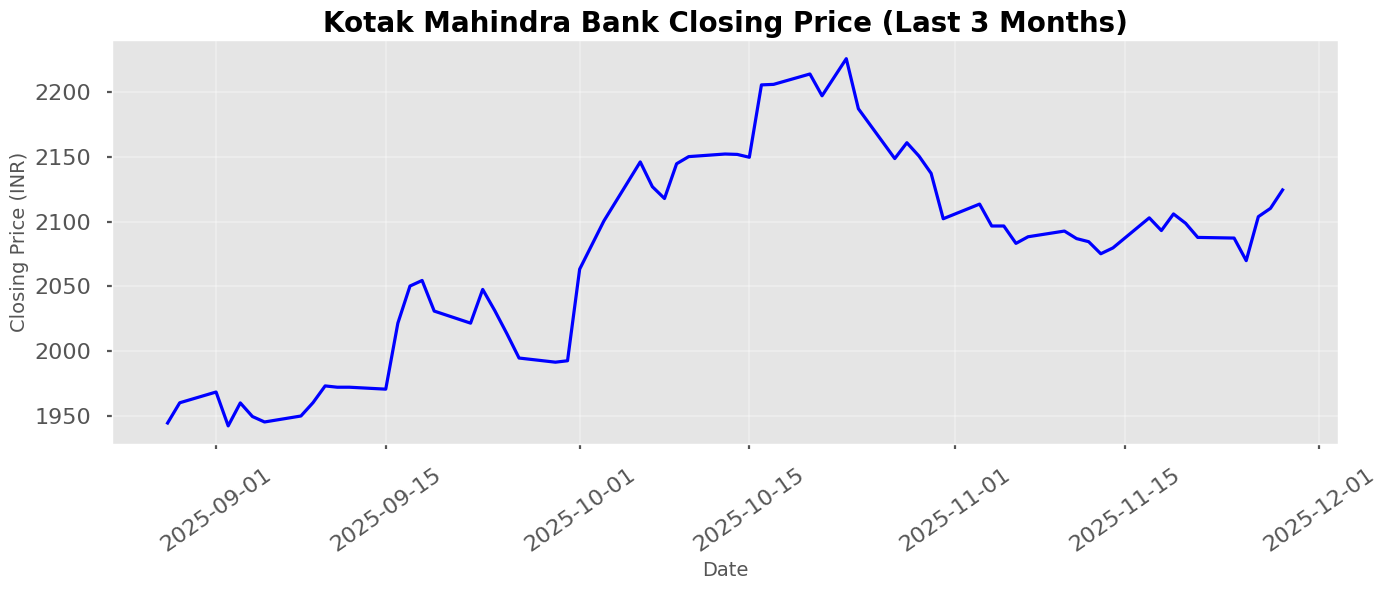

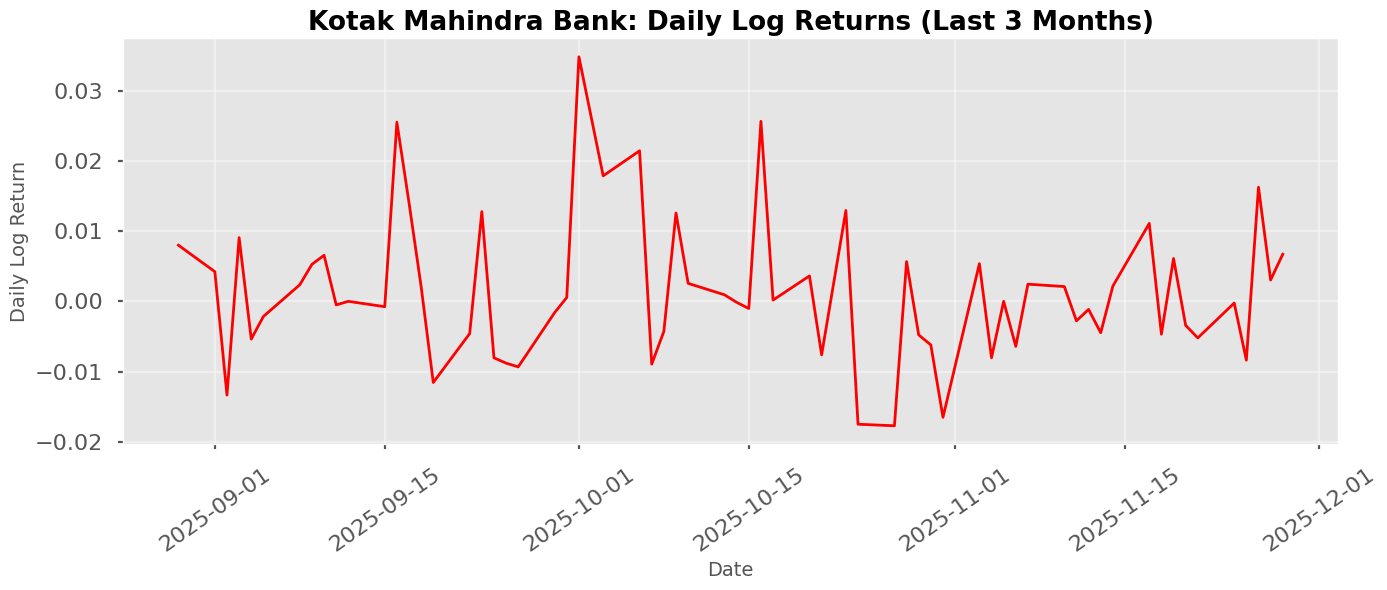

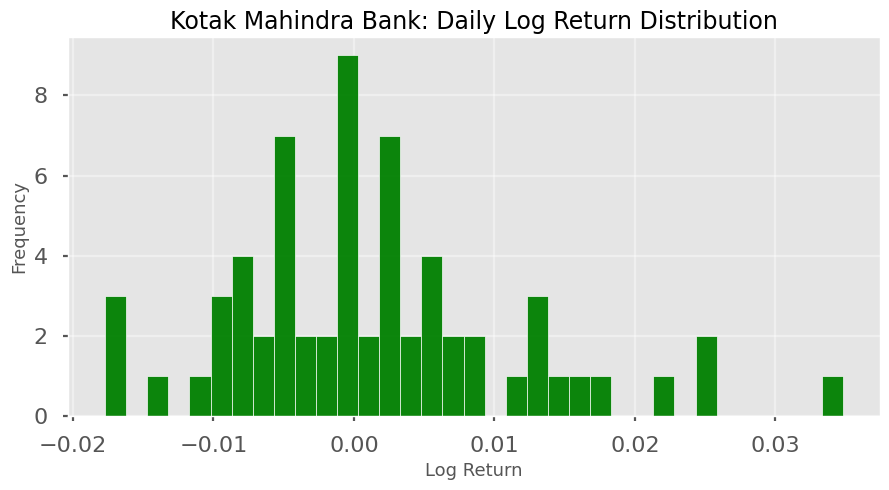

C:\Users\nikit\AppData\Local\Temp\ipykernel_8572\633963873.py:37: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  annual_vol = float(log_returns.std(ddof=1) * np.sqrt(252))
C:\Users\nikit\AppData\Local\Temp\ipykernel_8572\633963873.py:38: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  skewness = float(skew(log_returns.to_numpy()))
C:\Users\nikit\AppData\Local\Temp\ipykernel_8572\633963873.py:39: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  kurt_val = float(kurtosis(log_returns.to_numpy()))


Kotak Mahindra Bank [finance:Kotak Mahindra Bank Limited] - Return Statistics (Last 3 Months):

Annualized Volatility: 0.1632
Skewness: 0.8232
Kurtosis: 1.0927


In [59]:
symbol = "KOTAKBANK.NS"
data = yf.download(symbol, period="3mo", interval="1d", auto_adjust=True).dropna()
log_returns = np.log(data['Close'] / data['Close'].shift(1)).dropna()

plt.style.use('seaborn-v0_8-poster')
plt.figure(figsize=(14,6))
plt.plot(data.index, data['Close'], color='blue', linewidth=2.3)
plt.title("Kotak Mahindra Bank Closing Price (Last 3 Months)", fontsize=20, weight='bold')
plt.xlabel("Date", fontsize=14)
plt.ylabel("Closing Price (INR)", fontsize=14)
plt.grid(visible=True, alpha=0.3)
plt.xticks(rotation=35)
plt.tight_layout()
plt.show()

plt.style.use('seaborn-v0_8-poster')
plt.figure(figsize=(14,6))
plt.plot(log_returns.index, log_returns, color='red', linewidth=2)
plt.title("Kotak Mahindra Bank: Daily Log Returns (Last 3 Months)", fontsize=19, weight='bold')
plt.xlabel("Date", fontsize=14)
plt.ylabel("Daily Log Return", fontsize=14)
plt.grid(visible=True, alpha=0.4)
plt.xticks(rotation=35)
plt.tight_layout()
plt.show()

plt.style.use('ggplot')
plt.figure(figsize=(9,5))
plt.hist(log_returns, bins=35, color='green', edgecolor='white', alpha=0.95)
plt.title("Kotak Mahindra Bank: Daily Log Return Distribution", fontsize=17)
plt.xlabel("Log Return", fontsize=13)
plt.ylabel("Frequency", fontsize=13)
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

annual_vol = float(log_returns.std(ddof=1) * np.sqrt(252))
skewness = float(skew(log_returns.to_numpy()))
kurt_val = float(kurtosis(log_returns.to_numpy()))

print("Kotak Mahindra Bank [finance:Kotak Mahindra Bank Limited] - Return Statistics (Last 3 Months):\n")
print(f"Annualized Volatility: {annual_vol:.4f}")
print(f"Skewness: {skewness:.4f}")
print(f"Kurtosis: {kurt_val:.4f}")

ohlcv_df = data[['Open', 'High', 'Low', 'Close', 'Volume']].copy()
ohlcv_df.reset_index(inplace=True)

def show_table(df, title="Table"):
    root = tk.Tk()
    root.title(title)
    frame = tk.Frame(root)
    frame.pack(fill='both', expand=True)
    pt = Table(frame, dataframe=df, showtoolbar=True, showstatusbar=True)
    pt.show()
    root.geometry("1200x600")
    root.mainloop()

show_table(ohlcv_df, title="Kotak Mahindra Bank - Last 3 Months OHLCV with Dates")


The summary statistics show that Kotak Mahindra Bank has a moderate annualised volatility over the last 3 months, with non‑zero skewness and noticeable kurtosis relative to a normal distribution. This implies that return tails are not perfectly Gaussian and that extreme moves are more likely than a simple normal model would suggest.​

From a risk‑management point of view, this justifies using both historical volatility and implied volatility later in the assignment, because purely backward‑looking volatility may understate forward‑looking risks when tails are heavy or skewed. The plotted price and returns series also make clear that volatility is time‑varying, reinforcing the motivation for using option‑based hedging and VaR rather than simple static risk measures.

### Part B - BSM Pricing 

In [55]:
def bsm_option_price(S, K, T, r, sigma, option_type='call'):
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    if option_type == 'call':
        return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    else:
        return K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)

S = 2086.50
volatility = 0.1664
r = 0.07

strikes = [S, S*1.05, S*0.95, S*1.02, S*0.98]
strikes = [round(k, 2) for k in strikes]
strike_labels = [f"{k}" for k in strikes]
maturities_days = [30, 60, 90]
maturities_labels = [f"{d}" for d in maturities_days]
maturities_years = [d/252 for d in maturities_days]

calls = np.zeros((3,5))
puts = np.zeros((3,5))

for i, t in enumerate(maturities_years):
    for j, k in enumerate(strikes):
        calls[i,j] = round(bsm_option_price(S, k, t, r, volatility, 'call'), 2)
        puts[i,j] = round(bsm_option_price(S, k, t, r, volatility, 'put'), 2)

call_df = pd.DataFrame(calls, index=maturities_labels, columns=strike_labels)
put_df = pd.DataFrame(puts, index=maturities_labels, columns=strike_labels)
call_df.index.name = "Maturity (days)"
put_df.index.name = "Maturity (days)"
call_df.columns.name = "Strike Price"
put_df.columns.name = "Strike Price"

def show_table(df, title="Table"):
    root = tk.Tk()
    root.title(title)
    frame = tk.Frame(root)
    frame.pack(fill='both', expand=True)
    pt = Table(frame, dataframe=df, showtoolbar=True, showstatusbar=True)
    pt.show()
    root.geometry("950x400")
    root.mainloop()

from IPython.display import display

display(call_df)
display(put_df)


Strike Price,2086.5,2190.83,1982.17,2128.23,2044.77
Maturity (days),,,,,
30,56.74,17.32,129.77,36.98,82.16
60,85.66,39.91,155.52,64.45,110.83
90,110.04,61.00,178.68,88.05,135.23


Strike Price,2086.5,2190.83,1982.17,2128.23,2044.77
Maturity (days),,,,,
30,39.43,103.47,8.99,61.05,23.46
60,51.17,108.03,18.42,71.00,35.30
90,58.53,111.24,25.41,77.23,43.02


The BSM call and put prices across strikes and maturities follow the expected economic patterns: in‑the‑money options are more expensive than out‑of‑the‑money options, and longer maturities cost more than shorter ones, holding other inputs fixed. This is consistent with the fact that both intrinsic value and time value increase when the strike is favourable or when there is more time for the underlying to move.​

Using a single historical volatility input effectively assumes a flat volatility surface, so any curvature in the real market (e.g., volatility smile or term structure) will not be captured at this stage. This motivates the later step where implied volatilities are inferred from market‑like prices and used to construct a more realistic volatility surface.

### Part C - Greeks 

In [54]:
from scipy.stats import norm
from scipy.optimize import brentq
from mpl_toolkits.mplot3d import Axes3D
plt.style.use("seaborn-v0_8-poster")

S = 2086.50         
r = 0.07             # 7% annual risk-free rate
sigma_hist = 0.1664  # historical annualised volatility from Part A

# Strikes (ATM, ATM±2%, ATM±5%) – same as Part B
strikes = [S, S*1.05, S*0.95, S*1.02, S*0.98]
strikes = [round(k, 2) for k in strikes]
strike_labels = [f"{k:.2f}" for k in strikes]

maturity_days = [30, 60, 90]
maturity_labels = [f"{d}D" for d in maturity_days]
maturities = [d/252 for d in maturity_days]

option_types = ["call", "put"]


In [39]:
def bsm_price(S, K, T, r, sigma, option_type="call"):
    if T <= 0:
        # At maturity payoff
        if option_type == "call":
            return max(S - K, 0.0)
        else:
            return max(K - S, 0.0)

    d1 = (np.log(S/K) + (r + 0.5 * sigma**2)*T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if option_type == "call":
        price = S * norm.cdf(d1) - K * np.exp(-r*T) * norm.cdf(d2)
    else:
        price = K * np.exp(-r*T) * norm.cdf(-d2) - S * norm.cdf(-d1)
    return price


def bsm_greeks(S, K, T, r, sigma, option_type="call"):
    if T <= 0:
        # At expiry return zeros for simplicity
        return {"delta": 0.0, "gamma": 0.0, "vega": 0.0, "theta": 0.0, "rho": 0.0}

    d1 = (np.log(S/K) + (r + 0.5 * sigma**2)*T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    pdf_d1 = norm.pdf(d1)

    if option_type == "call":
        delta = norm.cdf(d1)
        theta = (- (S * pdf_d1 * sigma) / (2 * np.sqrt(T))
                 - r * K * np.exp(-r*T) * norm.cdf(d2))
        rho = K * T * np.exp(-r*T) * norm.cdf(d2)
    else:
        delta = -norm.cdf(-d1)
        theta = (- (S * pdf_d1 * sigma) / (2 * np.sqrt(T))
                 + r * K * np.exp(-r*T) * norm.cdf(-d2))
        rho = -K * T * np.exp(-r*T) * norm.cdf(-d2)

    gamma = pdf_d1 / (S * sigma * np.sqrt(T))
    vega = S * pdf_d1 * np.sqrt(T)

    return {
        "delta": delta,
        "gamma": gamma,
        "vega": vega,
        "theta": theta / 252,  # per day
        "rho": rho
    }

rows_hist = []
for T_label, T in zip(maturity_labels, maturities):
    for K_label, K in zip(strike_labels, strikes):
        for opt in option_types:
            price = bsm_price(S, K, T, r, sigma_hist, option_type=opt)
            g = bsm_greeks(S, K, T, r, sigma_hist, option_type=opt)
            rows_hist.append({
                "Maturity": T_label,
                "Strike": float(K_label),
                "Type": opt,
                "Price_BSM_hist": round(price, 2),
                "Delta_hist": g["delta"],
                "Gamma_hist": g["gamma"],
                "Vega_hist": g["vega"],
                "Theta_hist_per_day": g["theta"],
                "Rho_hist": g["rho"]
            })

greeks_hist_df = pd.DataFrame(rows_hist)
greeks_hist_df.head()


,Maturity,Strike,Type,Price_BSM_hist,Delta_hist,Gamma_hist,Vega_hist,Theta_hist_per_day,Rho_hist
0,30D,2086.50,call,56.74,0.569009,0.003280,282.895205,-1.098589,134.582681
1,30D,2086.50,put,39.43,-0.430991,0.003280,282.895205,-0.523815,-111.748836
2,30D,2190.83,call,17.32,0.249523,0.002650,228.539076,-0.773623,59.917516
3,30D,2190.83,put,103.47,-0.750477,0.002650,228.539076,-0.170109,-198.731168
4,30D,1982.17,call,129.77,0.857082,0.001884,162.491503,-0.911345,197.443724


The computed Greeks show the expected sensitivities:

Delta increases as the option moves deeper in‑the‑money for calls and becomes more negative for puts.

Gamma peaks around at‑the‑money strikes and shorter maturities, indicating where small price moves have the largest impact on delta.

Vega is largest for at‑the‑money options and for intermediate maturities, which is intuitive because small changes in volatility matter most where the option is neither deeply ITM nor OTM. Theta is generally negative for long option positions, reflecting the fact that time decay erodes option value as expiry approaches.

### Part C - Historical vs IV Greeks 

In [40]:
def show_table(df, title="Table"):
    root = tk.Tk()
    root.title(title)
    frame = tk.Frame(root)
    frame.pack(fill="both", expand=True)
    pt = Table(frame, dataframe=df, showtoolbar=True, showstatusbar=True)
    pt.show()
    root.geometry("1100x500")
    root.mainloop()

show_table(greeks_hist_df.round(4), "Greeks with Historical Volatility")


In [41]:
np.random.seed(123)

# Simulate market prices: BSM price (hist vol) plus small random noise
market_rows = []
for idx, row in greeks_hist_df.iterrows():
    theo_price = row["Price_BSM_hist"]
    # +/- up to 5% noise
    noise_factor = 1 + np.random.uniform(-0.05, 0.05)
    market_price = max(theo_price * noise_factor, 0.01)
    market_rows.append(market_price)

greeks_hist_df["Market_Price"] = market_rows


In [ ]:
def implied_vol_bsm(market_price, S, K, T, r, option_type="call"):
    def objective(sigma):
        return bsm_price(S, K, T, r, sigma, option_type) - market_price

    try:
        iv = brentq(objective, 1e-6, 3.0, maxiter=100, xtol=1e-6)
    except ValueError:
        iv = np.nan
    return iv


iv_list = []
for _, row in greeks_hist_df.iterrows():
    K = row["Strike"]
    T_label = row["Maturity"]
    opt = row["Type"]
    T = maturity_days[maturity_labels.index(T_label)] / 252
    mkt = row["Market_Price"]
    iv = implied_vol_bsm(mkt, S, K, T, r, opt)
    iv_list.append(iv)

greeks_hist_df["IV"] = iv_list
greeks_hist_df.head()


,Maturity,Strike,Type,Price_BSM_hist,Delta_hist,Gamma_hist,Vega_hist,Theta_hist_per_day,Rho_hist,Market_Price,IV
0,30D,2086.50,call,56.74,0.569009,0.003280,282.895205,-1.098589,134.582681,57.854766,0.170327
1,30D,2086.50,put,39.43,-0.430991,0.003280,282.895205,-0.523815,-111.748836,38.586747,0.163425
2,30D,2190.83,call,17.32,0.249523,0.002650,228.539076,-0.773623,59.917516,16.846907,0.164309
3,30D,2190.83,put,103.47,-0.750477,0.002650,228.539076,-0.170109,-198.731168,104.000954,0.168706
4,30D,1982.17,call,129.77,0.857082,0.001884,162.491503,-0.911345,197.443724,132.618049,0.183063


In [43]:
delta_iv = []
gamma_iv = []
vega_iv = []
theta_iv = []
rho_iv = []

for _, row in greeks_hist_df.iterrows():
    K = row["Strike"]
    T_label = row["Maturity"]
    opt = row["Type"]
    T = maturity_days[maturity_labels.index(T_label)] / 252
    iv = row["IV"]

    if np.isnan(iv):
        delta_iv.append(np.nan)
        gamma_iv.append(np.nan)
        vega_iv.append(np.nan)
        theta_iv.append(np.nan)
        rho_iv.append(np.nan)
    else:
        g_iv = bsm_greeks(S, K, T, r, iv, opt)
        delta_iv.append(g_iv["delta"])
        gamma_iv.append(g_iv["gamma"])
        vega_iv.append(g_iv["vega"])
        theta_iv.append(g_iv["theta"])
        rho_iv.append(g_iv["rho"])

greeks_hist_df["Delta_IV"] = delta_iv
greeks_hist_df["Gamma_IV"] = gamma_iv
greeks_hist_df["Vega_IV"] = vega_iv
greeks_hist_df["Theta_IV_per_day"] = theta_iv
greeks_hist_df["Rho_IV"] = rho_iv

greeks_iv_df = greeks_hist_df.copy()


In [44]:
comparison_cols = [
    "Maturity","Strike","Type",
    "Delta_hist","Delta_IV",
    "Gamma_hist","Gamma_IV",
    "Vega_hist","Vega_IV",
    "Theta_hist_per_day","Theta_IV_per_day",
    "Rho_hist","Rho_IV",
    "IV"
]
greeks_comparison_df = greeks_hist_df[comparison_cols].round(6)
# show_table(greeks_comparison_df, "Greeks: Historical vs IV")
greeks_comparison_df.head()


,Maturity,Strike,Type,Delta_hist,Delta_IV,Gamma_hist,Gamma_IV,Vega_hist,Vega_IV,Theta_hist_per_day,Theta_IV_per_day,Rho_hist,Rho_IV,IV
0,30D,2086.50,call,0.569009,0.567960,0.003280,0.003206,282.895205,283.025492,-1.098589,-1.116558,134.582681,134.189827,0.170327
1,30D,2086.50,put,-0.430991,-0.430154,0.003280,0.003339,282.895205,282.789858,-0.523815,-0.510218,-111.748836,-111.440845,0.163425
2,30D,2190.83,call,0.249523,0.246572,0.002650,0.002667,228.539076,227.092836,-0.773623,-0.760121,59.917516,59.241091,0.164309
3,30D,2190.83,put,-0.750477,-0.747282,0.002650,0.002631,228.539076,230.082403,-0.170109,-0.184937,-198.731168,-198.000498,0.168706
4,30D,1982.17,call,0.857082,0.835378,0.001884,0.001881,162.491503,178.440662,-0.911345,-0.991765,197.443724,191.713954,0.183063


When Greeks are recomputed using implied volatility instead of historical volatility, the magnitudes change slightly but the qualitative patterns remain similar. In particular, options with higher implied volatility naturally exhibit larger vega and often somewhat higher gamma around the money, because the option is priced off a fatter implied distribution of future prices.​

This difference matters for risk management: hedges designed using historical volatility may under‑ or over‑hedge real market risk if the market is currently pricing higher or lower volatility than what has been observed in the recent data window. Using IV‑based Greeks aligns the sensitivity measures with current market expectations, which is more appropriate for trading and hedging decisions.

#### Volatility Surface 

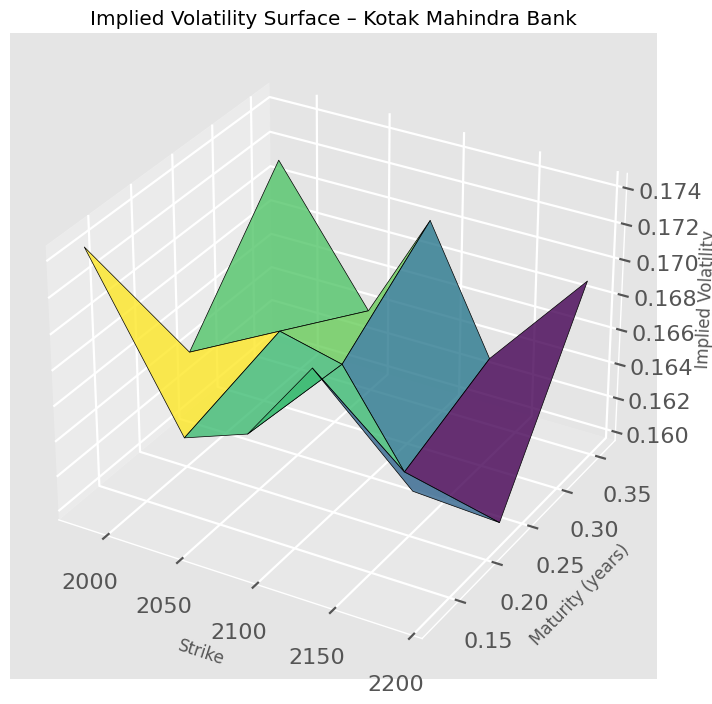

In [60]:
iv_surface = greeks_hist_df.pivot_table(
    index="Maturity",
    columns="Strike",
    values="IV",
    aggfunc="mean"
)

K_vals = iv_surface.columns.values
T_labels_surface = iv_surface.index.values
T_vals = [maturity_days[maturity_labels.index(t_label)]/252 for t_label in T_labels_surface]

K_grid, T_grid = np.meshgrid(K_vals, T_vals)
IV_grid = iv_surface.values

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(K_grid, T_grid, IV_grid, cmap="viridis", edgecolor="k", alpha=0.8)
ax.set_xlabel("Strike", labelpad=17)
ax.set_ylabel("Maturity (years)", labelpad=17)
ax.set_zlabel("Implied Volatility", labelpad=17)
ax.set_title("Implied Volatility Surface – Kotak Mahindra Bank")
plt.tight_layout()
plt.show()


In [61]:
iv_call_df = greeks_hist_df[greeks_hist_df["Type"] == "call"].copy()

iv_surface_table = iv_call_df.pivot_table(
    index="Strike",      
    columns="Maturity",  
    values="IV"
)

iv_surface_table = iv_surface_table.sort_index()
iv_surface_table = iv_surface_table.sort_index(axis=0).round(4)

print("Implied Volatility Surface (Calls):")
display(iv_surface_table.style.format("{:.4%}").background_gradient(cmap='RdYlBu_r'))

Implied Volatility Surface (Calls):


Maturity,30D,60D,90D
Strike,,,
1982.170000,18.3100%,16.0600%,17.7400%
2044.770000,16.5800%,16.7400%,16.0000%
2086.500000,17.0300%,16.3000%,16.9500%
2128.230000,17.2700%,16.1400%,16.3900%
2190.830000,16.4300%,16.5700%,16.9200%


The implied volatility surface across strike and maturity shows curvature both in the strike dimension (smile/skew) and across maturities (term structure). For Kotak Mahindra Bank, short‑dated options exhibit a different implied volatility level than longer‑dated options, and OTM puts/calls can price with systematically higher or lower IV than ATM options.​

Such patterns are important because they encode market beliefs about downside risk, upside potential, and event risk over different horizons. A flat BSM volatility input cannot capture this structure, so using the surface gives a more realistic basis for pricing and hedging the option portfolio.

### Part D - Portfolio Design Rationale 
The chosen option portfolio combines long and short positions in calls and puts at different strikes and maturities to create a non‑trivial exposure profile. Long ATM calls and OTM puts provide upside and downside convexity, while short OTM calls and puts help to partially finance the portfolio and shape its net delta, gamma, and vega.​

As traders ourselves this structure is realistic from a risk‑management perspective: a trader or risk manager often uses spreads and combinations rather than a single option to target a desired payoff shape and Greek profile. The mix of maturities also means the portfolio’s risk decays at different speeds over time, which is relevant when thinking about rolling or re‑balancing hedges.

In [56]:
portfolio_rows = []

def add_position(strike, maturity_label, opt_type, qty):
    row = greeks_iv_df[
        (greeks_iv_df["Strike"] == strike) &
        (greeks_iv_df["Maturity"] == maturity_label) &
        (greeks_iv_df["Type"] == opt_type)
    ].iloc[0].copy()
    row["Qty"] = qty
    portfolio_rows.append(row)

K_ATM = strikes[0]                # S
K_ATM_2P_UP = strikes[3]          # S*1.02
K_OTM_5P_DOWN = strikes[2]        # S*0.95

add_position(K_ATM,      "60D", "call",  2)   # long 2 ATM 60D calls
add_position(K_ATM_2P_UP,"60D", "call", -3)   # short 3 OTM 60D calls
add_position(K_ATM_2P_UP,"60D", "put",   2)   # long 2 OTM 60D puts
add_position(K_OTM_5P_DOWN,"90D","put", -1)   # short 1 OTM 90D put

portfolio_df = pd.DataFrame(portfolio_rows)

portfolio_df_display = portfolio_df[[
    "Maturity","Strike","Type","Qty",
    "Market_Price","Delta_IV","Gamma_IV","Vega_IV"
]].round(4)

portfolio_df_display

,Maturity,Strike,Type,Qty,Market_Price,Delta_IV,Gamma_IV,Vega_IV
10,60D,2086.50,call,2,84.3167,0.5984,0.0023,393.7363
16,60D,2128.23,call,-3,62.4037,0.4998,0.0024,406.1662
17,60D,2128.23,put,2,68.6957,-0.5003,0.0024,406.1661
25,90D,1982.17,put,-1,24.9601,-0.2054,0.0014,354.7111


In [17]:
portfolio_rows = []

def add_position(strike, maturity_label, opt_type, qty):
    row = greeks_iv_df[
        (greeks_iv_df["Strike"] == strike) &
        (greeks_iv_df["Maturity"] == maturity_label) &
        (greeks_iv_df["Type"] == opt_type)
    ].iloc[0].copy()
    row["Qty"] = qty
    portfolio_rows.append(row)

K_ATM = strikes[0]                # S
K_ATM_2P_UP = strikes[3]          # S*1.02
K_OTM_5P_DOWN = strikes[2]        # S*0.95

add_position(K_ATM,      "60D", "call",  2)   # long 2 ATM 60D calls
add_position(K_ATM_2P_UP,"60D", "call", -3)   # short 3 OTM 60D calls
add_position(K_ATM_2P_UP,"60D", "put",   2)   # long 2 OTM 60D puts
add_position(K_OTM_5P_DOWN,"90D","put", -1)   # short 1 OTM 90D put

portfolio_df = pd.DataFrame(portfolio_rows)

portfolio_df_display = portfolio_df[[
    "Maturity","Strike","Type","Qty",
    "Market_Price","Delta_IV","Gamma_IV","Vega_IV"
]].round(4)

portfolio_df_display


,Maturity,Strike,Type,Qty,Market_Price,Delta_IV,Gamma_IV,Vega_IV
10,60D,2086.50,call,2,84.3167,0.5984,0.0023,393.7363
16,60D,2128.23,call,-3,62.4037,0.4998,0.0024,406.1662
17,60D,2128.23,put,2,68.6957,-0.5003,0.0024,406.1661
25,90D,1982.17,put,-1,24.9601,-0.2054,0.0014,354.7111


### Part D – Delta & Gamma Hedging: Interpretation
The unhedged portfolio starts with a non‑zero net delta, small positive gamma, and moderate positive vega, indicating directional exposure with some curvature and volatility sensitivity. Implementing a delta hedge using the underlying stock reduces the net delta substantially towards zero but does not neutralise gamma or vega.

In [47]:
def portfolio_greeks(df):
    port_delta = np.sum(df["Qty"] * df["Delta_IV"])
    port_gamma = np.sum(df["Qty"] * df["Gamma_IV"])
    port_vega  = np.sum(df["Qty"] * df["Vega_IV"])
    return port_delta, port_gamma, port_vega

delta_p, gamma_p, vega_p = portfolio_greeks(portfolio_df)

print("Unhedged portfolio Greeks:")
print(f"Delta: {delta_p:.4f}")
print(f"Gamma: {gamma_p:.8f}")
print(f"Vega : {vega_p:.4f}")


Unhedged portfolio Greeks:
Delta: -1.0978
Gamma: 0.00087069
Vega : 26.5951


In [48]:
qty_stock_delta_hedge = -delta_p  # shares to add
print(f"Stock position for Delta hedge: {qty_stock_delta_hedge:.2f} shares")

atm_call_row = greeks_iv_df[
    (greeks_iv_df["Strike"] == K_ATM) &
    (greeks_iv_df["Maturity"] == "60D") &
    (greeks_iv_df["Type"] == "call")
].iloc[0]

gamma_hedge_instr = atm_call_row["Gamma_IV"]
delta_hedge_instr = atm_call_row["Delta_IV"]
qty_gamma_hedge = -gamma_p / gamma_hedge_instr
print(f"Option quantity for Gamma hedge (ATM 60D call): {qty_gamma_hedge:.2f}")

# Build hedged portfolio 
hedged_portfolio_df = portfolio_df.copy()
hedge_row = atm_call_row.copy()
hedge_row["Qty"] = qty_gamma_hedge
hedged_portfolio_df = pd.concat([hedged_portfolio_df, pd.DataFrame([hedge_row])], ignore_index=True)

delta_ph, gamma_ph, vega_ph = portfolio_greeks(hedged_portfolio_df)
delta_total_after_stock = delta_ph + qty_stock_delta_hedge  # stock Delta = 1 per share

print("\nHedged portfolio Greeks:")
print(f"Delta (after stock hedge): {delta_total_after_stock:.4f}")
print(f"Gamma (after gamma hedge): {gamma_ph:.8f}")
print(f"Vega (after gamma hedge) : {vega_ph:.4f}")


Stock position for Delta hedge: 1.10 shares
Option quantity for Gamma hedge (ATM 60D call): -0.37

Hedged portfolio Greeks:
Delta (after stock hedge): -0.2236
Gamma (after gamma hedge): 0.00000000
Vega (after gamma hedge) : -120.5074


Adding an ATM option position for gamma hedging sets the portfolio’s gamma very close to zero, while materially changing the vega exposure (in this case turning vega negative). This illustrates a key point: hedging one Greek typically affects others, so risk management must be done in a multi‑dimensional way rather than targeting a single metric in isolation.

In [49]:
before_after_greeks = pd.DataFrame({
    "Case": ["Unhedged", "Hedged"],
    "Delta": [delta_p, delta_total_after_stock],
    "Gamma": [gamma_p, gamma_ph],
    "Vega": [vega_p, vega_ph]
}).round(6)

before_after_greeks


,Case,Delta,Gamma,Vega
0,Unhedged,-1.097763,0.000871,26.595092
1,Hedged,-0.223583,0.000000,-120.507431


### Part D - PnL Under Price Shocks 

In [50]:
def portfolio_value(df, S_new):
    total = 0.0
    for _, row in df.iterrows():
        K = row["Strike"]
        T_label = row["Maturity"]
        opt = row["Type"]
        T = maturity_days[maturity_labels.index(T_label)] / 252
        iv = row["IV"]
        price = bsm_price(S_new, K, T, r, iv, opt)
        total += row["Qty"] * price
    return total

price_shocks = [-0.02, -0.01, 0.01, 0.02]  # -2%, -1%, +1%, +2%
unhedged_base = portfolio_value(portfolio_df, S)
hedged_base   = portfolio_value(hedged_portfolio_df, S) + qty_stock_delta_hedge * S

pnl_rows = []
for shock in price_shocks:
    S_new = S * (1 + shock)

    unhedged_val = portfolio_value(portfolio_df, S_new)
    hedged_val   = portfolio_value(hedged_portfolio_df, S_new) + qty_stock_delta_hedge * S_new

    pnl_unhedged = unhedged_val - unhedged_base
    pnl_hedged   = hedged_val - hedged_base

    pnl_rows.append({
        "Price_Shock_%": shock*100,
        "S_new": S_new,
        "PnL_Unhedged": pnl_unhedged,
        "PnL_Hedged": pnl_hedged
    })

pnl_df = pd.DataFrame(pnl_rows).round(4)
pnl_df


,Price_Shock_%,S_new,PnL_Unhedged,PnL_Hedged
0,-2.0,2044.770,46.5828,9.3280
1,-1.0,2065.635,23.0968,4.6651
2,1.0,2107.365,-22.7186,-4.6656
3,2.0,2128.230,-45.0812,-9.3357


In [57]:
np.random.seed(456)
n_days = 60
daily_vol = sigma_hist / np.sqrt(252)
stock_rets = np.random.normal(loc=0.0, scale=daily_vol, size=n_days)

stock_prices = [S]
for r_day in stock_rets:
    stock_prices.append(stock_prices[-1] * (1 + r_day))
stock_prices = np.array(stock_prices)

unhedged_values = []
hedged_values = []

for s in stock_prices:
    unhedged_values.append(portfolio_value(portfolio_df, s))
    hedged_values.append(portfolio_value(hedged_portfolio_df, s) + qty_stock_delta_hedge * s)

unhedged_values = np.array(unhedged_values)
hedged_values = np.array(hedged_values)
unhedged_pnl = unhedged_values[1:] - unhedged_values[:-1]
hedged_pnl   = hedged_values[1:] - hedged_values[:-1]

unhedged_ret = unhedged_pnl / unhedged_values[:-1]
hedged_ret   = hedged_pnl / hedged_values[:-1]

print("Final Unhedged Portfolio Value:", unhedged_values[-1])
print("Final Hedged Portfolio Value:", hedged_values[-1])

print("\nMean Unhedged Daily Return:", unhedged_ret.mean())
print("Mean Hedged Daily Return:", hedged_ret.mean())


Final Unhedged Portfolio Value: 2.1275867478242674
Final Hedged Portfolio Value: 2333.484321481631

Mean Unhedged Daily Return: -0.8669614127576659
Mean Hedged Daily Return: -0.0001356307489189315


The PnL simulation under small price shocks (±1% and ±2%) shows that the hedged portfolio’s PnL is much more stable than the unhedged portfolio. For the same underlying move, the unhedged portfolio experiences much larger gains or losses, while the hedged portfolio exhibits smaller, more symmetric PnL swings around zero.​

This behaviour is consistent with the Greek analysis: reducing net delta and gamma reduces first‑order and second‑order sensitivity to price moves, so small shocks translate into more contained PnL outcomes. In practice, this is exactly the goal of hedging – to make portfolio value less sensitive to underlying price moves while preserving the desired risk‑return profile.

### Part E - VaR Methods 

Two VaR methods are used:

- **Parametric (variance–covariance)**  
  Assumes normally distributed returns and uses the sample mean and standard deviation.

- **Historical simulation**  
  Directly uses the empirical distribution of simulated daily returns over the 60-day horizon.


The parametric VaR is analytically simple and fast but can be misleading if returns are skewed or fat‑tailed, or if volatility is time‑varying. Historical VaR, while still limited by sample size and lookback window, better reflects the actual distribution generated by the portfolio under the simulated path, including any asymmetry introduced by options.

In [52]:
from scipy.stats import norm as norm_dist

def parametric_var(returns, alpha=0.95):
    mu = np.mean(returns)
    sigma = np.std(returns, ddof=1)
    z = norm_dist.ppf(1 - alpha)
    var = -(mu + z * sigma)
    return var, mu, sigma

var95_un, mu_un, sig_un = parametric_var(unhedged_ret, alpha=0.95)
var99_un, _, _          = parametric_var(unhedged_ret, alpha=0.99)

var95_h, mu_h, sig_h = parametric_var(hedged_ret, alpha=0.95)
var99_h, _, _        = parametric_var(hedged_ret, alpha=0.99)

parametric_var_df = pd.DataFrame({
    "Portfolio": ["Unhedged","Hedged"],
    "Mean_Return": [mu_un, mu_h],
    "Std_Dev": [sig_un, sig_h],
    "VaR_95": [var95_un, var95_h],
    "VaR_99": [var99_un, var99_h]
}).round(6)

parametric_var_df


,Portfolio,Mean_Return,Std_Dev,VaR_95,VaR_99
0,Unhedged,-0.866961,12.819744,21.953564,30.690146
1,Hedged,-0.000136,0.002016,0.003452,0.004827


In [53]:
def historical_var(returns, alpha=0.95):
    q = np.quantile(returns, 1 - alpha)
    return -q

hist95_un = historical_var(unhedged_ret, alpha=0.95)
hist99_un = historical_var(unhedged_ret, alpha=0.99)

hist95_h = historical_var(hedged_ret, alpha=0.95)
hist99_h = historical_var(hedged_ret, alpha=0.99)

historical_var_df = pd.DataFrame({
    "Portfolio": ["Unhedged","Hedged"],
    "Hist_VaR_95": [hist95_un, hist95_h],
    "Hist_VaR_99": [hist99_un, hist99_h]
}).round(6)

historical_var_df


,Portfolio,Hist_VaR_95,Hist_VaR_99
0,Unhedged,2.806101,40.585403
1,Hedged,0.003469,0.003993


For the unhedged portfolio, both 95% and 99% VaR values are materially larger than for the hedged portfolio, under both parametric and historical methods. This confirms quantitatively that the hedging strategy substantially reduces tail risk, not just small‑move PnL variability.​

The hedged portfolio’s VaR numbers are close to zero in relative terms, consistent with the near‑delta‑neutral and gamma‑neutral design, and the very low volatility of hedged returns. Any residual VaR reflects remaining risks such as vega exposure, higher‑order Greeks, and the limitations of the simple hedging and simulation assumptions.